### 🌸 Analisis Regresi Linear pada Data Bunga Iris

#### Dataset yang digunakan adalah data bunga iris yang berisi informasi mengenai ukuran sepal dan petal. Variabel yang digunakan dalam analisis meliputi sepal_length, sepal_width, petal_length, dan petal_width. Data ini digunakan untuk menganalisis hubungan antar variabel menggunakan regresi linear.

#### 1. Import Package 

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (8,6)

#### 2. Import Data

In [10]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### 3. Preview Data

In [11]:
print("Jumlah Data:", df.shape)
df.info()
df.describe()

Jumlah Data: (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


#### 4. Visualisasi Awal (Pairplot)

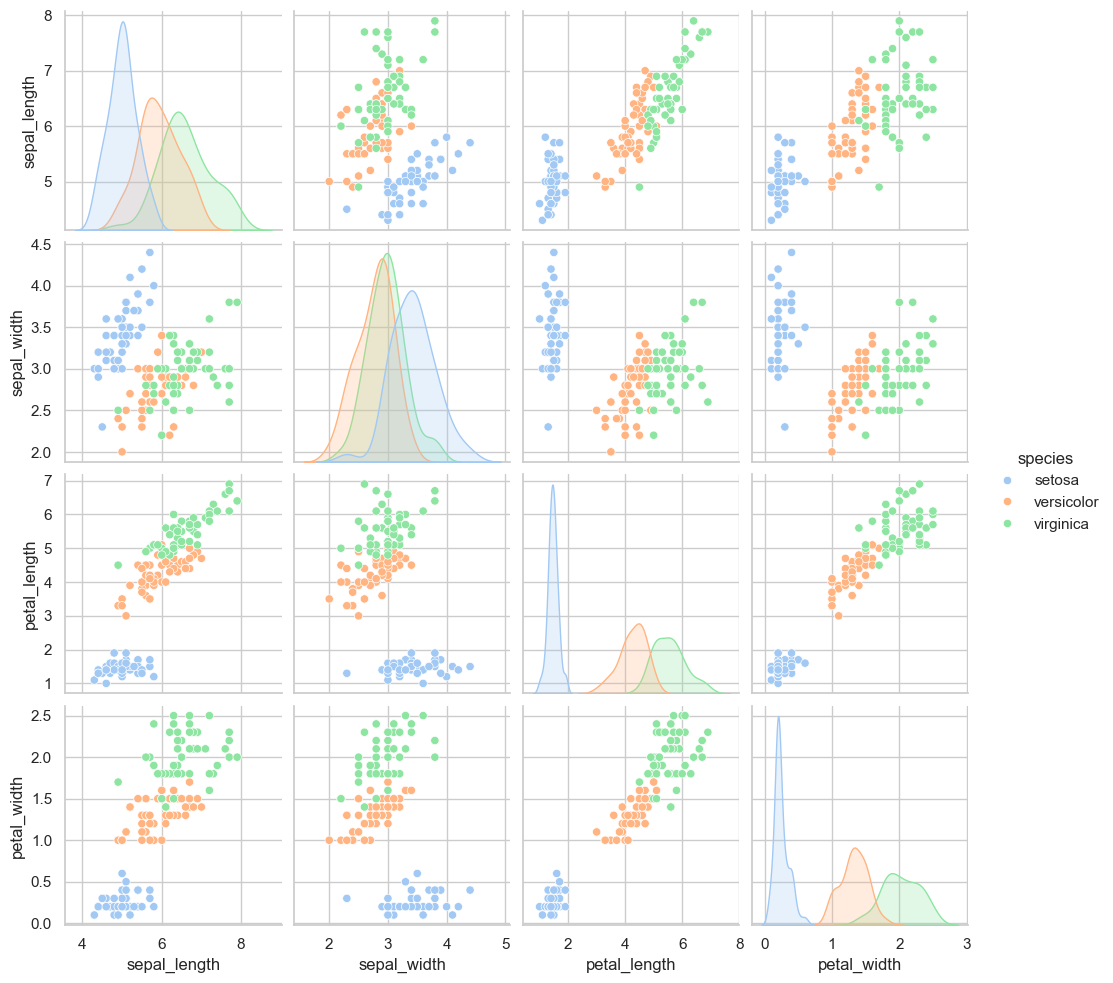

In [12]:
sns.pairplot(df, hue="species")
plt.show()

#### 5. Regresi Linear Berganda

In [13]:
X = df[['sepal_length', 'sepal_width', 'petal_width']]
y = df['petal_length']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           petal_length   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1473.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          6.98e-109
Time:                        10:12:11   Log-Likelihood:                -39.408
No. Observations:                 150   AIC:                             86.82
Df Residuals:                     146   BIC:                             98.86
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2627      0.297     -0.883   

#### 6. Cek Asumsi Regresi

#### a. Normalitas Residual

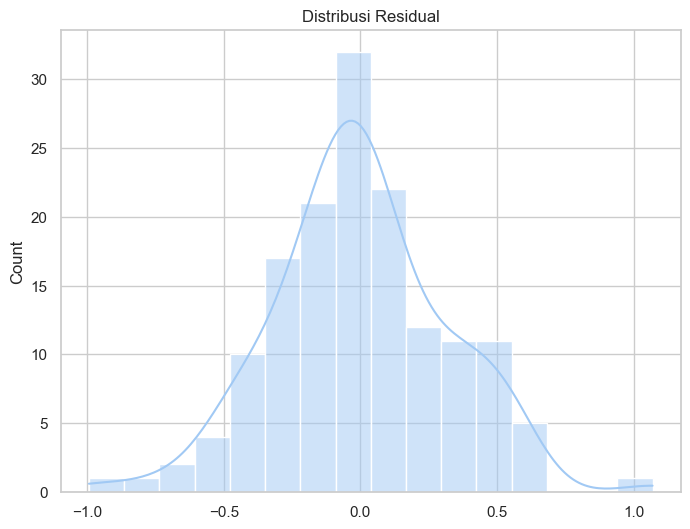

ShapiroResult(statistic=np.float64(0.9887528719342435), pvalue=np.float64(0.2709796043793913))

In [14]:
residuals = model.resid

sns.histplot(residuals, kde=True)
plt.title("Distribusi Residual")
plt.show()

stats.shapiro(residuals)

#### b. Multikolinearitas

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variabel"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Variabel,VIF
0,const,130.416081
1,sepal_length,3.415733
2,sepal_width,1.305515
3,petal_width,3.889961


#### c. Heteroskedastisitas

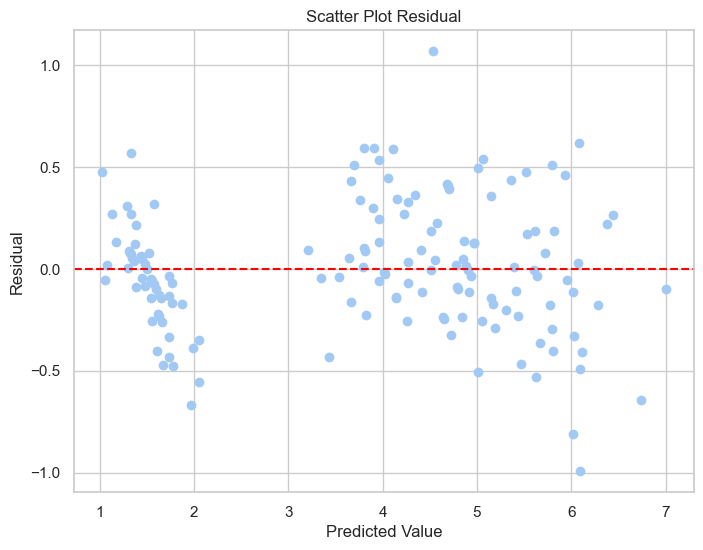

In [18]:
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Scatter Plot Residual")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.show()

#### 7. Model Regresi Linear Sederhana

In [20]:
X_simple = df[['sepal_length']]
y = df['petal_length']

X_simple = sm.add_constant(X_simple)

model_simple = sm.OLS(y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:           petal_length   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     468.6
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.04e-47
Time:                        10:15:50   Log-Likelihood:                -190.57
No. Observations:                 150   AIC:                             385.1
Df Residuals:                     148   BIC:                             391.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -7.1014      0.507    -14.016   

#### 🧠 Interpretasi Model 
Model regresi linear sederhana menunjukkan adanya hubungan antara sepal_length dan petal_length. Koefisien regresi bernilai positif, yang berarti semakin panjang sepal, maka panjang petal juga cenderung meningkat.

#### 🌸Visualisasi Regresi Linear Sederhana

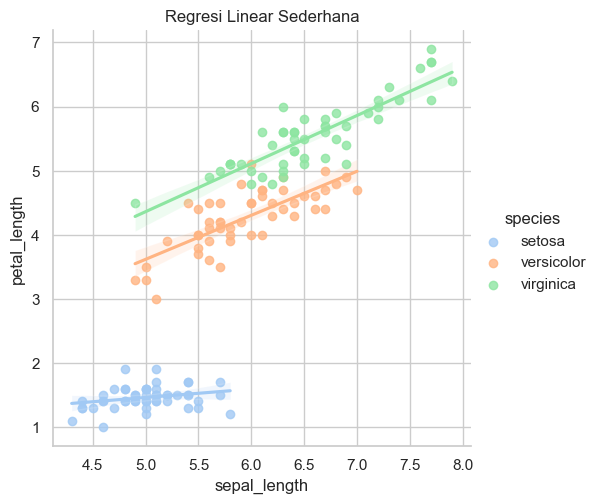

In [22]:
sns.lmplot(x="sepal_length", y="petal_length", data=df, hue="species")
plt.title("Regresi Linear Sederhana")
plt.show()

#### 8. Adjusted R-Square

In [21]:
print("Adjusted R-Square:", model.rsquared_adj)

Adjusted R-Square: 0.9673544769814524


#### 🧠 Interpretasi 
Nilai Adjusted R-Square menunjukkan seberapa besar variabel independen mampu menjelaskan variabel dependen. Nilai yang mendekati 1 menunjukkan bahwa model memiliki kemampuan yang baik dalam menjelaskan variasi data.